# LIBERO shared-autonomy experiments — success-rate analysis

Analyses every run written by [`experiment.py`](experiment.py) into
`outputs/pi05_libero_experiments/`. Each run directory holds `config.yaml`
(the resolved configuration, including the corruption / adapter matrices that
were in force), `trials.jsonl` (one record per completed trial) and, per
trial, a `.npz` of per-step arrays and an `.mp4`.

All runs are loaded by default; set `RUN_DIRS` by hand to look at a subset.

> **Read the caveats at the bottom before quoting any number from here.**
> Each condition has ~10 trials from a single operator — far too few to
> separate the conditions statistically.

Note on one field: in runs recorded before 2026-08-28 the `user_reads` value in
`trials.jsonl` is a session-cumulative counter rather than a per-trial one.
This notebook derives per-trial reads from the `.npz` step arrays instead, so
it is correct for old and new runs alike.

In [1]:
import json
from itertools import combinations
from math import atan2, degrees, sqrt
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from scipy import stats

# works whether the kernel starts in this folder or at the repo root
CANDIDATES = [Path("../../outputs/pi05_libero_experiments"), Path("outputs/pi05_libero_experiments")]
RUNS_ROOT = next((p for p in CANDIDATES if p.exists()), None)
if RUNS_ROOT is None:
    raise FileNotFoundError(f"no experiment output directory found; tried {[str(p) for p in CANDIDATES]}")

DEADBAND = 0.05  # matches teleop_input.DEADBAND

all_dirs = sorted(p for p in RUNS_ROOT.iterdir() if p.is_dir())
RUN_DIRS = [p for p in all_dirs if (p / "trials.jsonl").exists()]
aborted = [p.name for p in all_dirs if p not in RUN_DIRS]

print(f"{len(RUN_DIRS)} runs with data:")
for p in RUN_DIRS:
    print(" ", p.name)
if aborted:
    print(f"\nSkipped (no trials.jsonl — started but never ran a trial): {', '.join(aborted)}")

4 runs with data:
  20260828_154259_shared_flow_control
  20260828_155551_reverse_flow_control
  20260828_160610_shared_flow_control_deterministic_corruption
  20260828_161748_reverse_flow_control

Skipped (no trials.jsonl — started but never ran a trial): 20260828_160549_shared_flow_control_deterministic_corruption


## Load the runs

`trials.jsonl` holds one JSON object per *completed* trial; a skipped trial
leaves no record, so `trial` indices can have gaps. Each run gets a short
label built from what actually varied: the control mode, whether the operator's
command was corrupted by a matrix `M`, and whether the flow reversal used an
adapter `F`.

In [2]:
MODE_SHORT = {
    "shared_flow_control": "FC",
    "shared_reverse_flow_steering": "RFS",
    "shared_override": "override",
    "teleop": "teleop",
    "policy": "policy",
}


def label_for(config: dict) -> str:
    mode = MODE_SHORT.get(config["mode"], config["mode"])
    if config["mode"] == "shared_flow_control":
        mode += f" tau={config['tau']}"
    tags = []
    if config.get("corruption_matrix") is not None:
        tags.append("+M")
    if config.get("flow_adapter_matrix") is not None:
        tags.append("+F")
    return mode + ("".join(tags))


def load_run(run_dir: Path) -> tuple[pd.DataFrame, dict]:
    trials = [
        json.loads(line) for line in (run_dir / "trials.jsonl").read_text().splitlines() if line.strip()
    ]
    config = yaml.safe_load((run_dir / "config.yaml").read_text())
    df = pd.DataFrame(trials)
    df["run"] = run_dir.name
    df["label"] = label_for(config)
    df["mode"] = config["mode"]
    df["corrupted"] = config.get("corruption_matrix") is not None
    df["adapted"] = config.get("flow_adapter_matrix") is not None
    df["run_dir"] = str(run_dir)
    return df, config


frames, configs = [], {}
for run_dir in RUN_DIRS:
    df, config = load_run(run_dir)
    frames.append(df)
    configs[run_dir.name] = config

trials = pd.concat(frames, ignore_index=True)
LABEL = {run: label_for(c) for run, c in configs.items()}  # run id -> short label
ORDER = list(LABEL)  # runs in chronological order
print(f"{len(trials)} trials over {trials['run'].nunique()} runs")
trials[["run", "label", "trial", "task_id", "success", "steps", "duration_s"]].head()

39 trials over 4 runs


,run,label,trial,task_id,success,steps,duration_s
0,20260828_154259_shared_flow_control,FC tau=8,0,6,False,300,19.67
1,20260828_154259_shared_flow_control,FC tau=8,2,0,False,300,19.46
2,20260828_154259_shared_flow_control,FC tau=8,3,4,False,300,19.46
3,20260828_154259_shared_flow_control,FC tau=8,4,8,True,87,6.88
4,20260828_154259_shared_flow_control,FC tau=8,5,7,True,70,5.76


## What was actually run

Anything that differs between runs other than the intended factor is a
confound, so list the settings that are not identical across all of them.

In [3]:
keys = [
    "name",
    "mode",
    "tau",
    "suite",
    "prompt",
    "n_trials",
    "seed",
    "task_order",
    "input_noise",
    "max_steps",
    "deterministic_corruption",
    "flow_reversal_adapter",
    "policy_path",
    "n_action_steps",
]
setup = pd.DataFrame({LABEL[run]: {k: config.get(k) for k in keys} for run, config in configs.items()})
setup.loc["schedule"] = [str(configs[r].get("schedule")) for r in ORDER]
differing = setup[setup.nunique(axis=1) > 1]
print("Settings that differ between runs (everything else is identical):")
differing

Settings that differ between runs (everything else is identical):


,FC tau=8,RFS,FC tau=8+M,RFS+M+F
name,shared_flow_control,reverse_flow_control,shared_flow_control_deterministic_corruption,reverse_flow_control
mode,shared_flow_control,shared_reverse_flow_steering,shared_flow_control,shared_reverse_flow_steering


## The matrices that were in force

`M` (3x3) multiplies the operator's x/y/z command at every control step;
`F` (7x7) multiplies the policy's velocity field during the *reverse*
integration of `shared_reverse_flow_steering`. Both are recorded into the run's
`config.yaml`, so the analysis does not depend on those YAML files still
holding the same values.

In [4]:
def describe_rotation(matrix: np.ndarray) -> str:
    """Say whether a 3x3 is a rotation about z, and by how much."""
    if matrix.shape != (3, 3):
        return ""
    if np.allclose(matrix, np.eye(3)):
        return "identity (no-op)"
    orthonormal = np.allclose(matrix @ matrix.T, np.eye(3), atol=1e-3) and np.isclose(
        np.linalg.det(matrix), 1, atol=1e-3
    )
    angle = degrees(atan2(matrix[1, 0], matrix[0, 0]))
    return (
        f"rotation about z by {angle:+.0f} deg"
        if orthonormal
        else f"not a rotation (det={np.linalg.det(matrix):.3f})"
    )


AXES = ["dx", "dy", "dz", "droll", "dpitch", "dyaw", "grip"]
for run in ORDER:
    config = configs[run]
    print(f"=== {LABEL[run]}  ({run})")
    M = config.get("corruption_matrix")
    F = config.get("flow_adapter_matrix")
    if M is None:
        print("  M: none — the operator's command is passed through untouched")
    else:
        M = np.array(M)
        print(f"  M: {describe_rotation(M)}")
        display(pd.DataFrame(M, index=AXES[:3], columns=AXES[:3]))
    if F is None:
        print("  F: none — the flow reversal uses the policy's own velocity field")
    else:
        F = np.array(F)
        zero_rows = [AXES[i] for i in range(7) if np.allclose(F[i], 0)]
        print(f"  F: translation block is {describe_rotation(F[:3, :3])}")
        if zero_rows:
            print(
                f"     rows that are entirely zero: {', '.join(zero_rows)} "
                f"-> the reversal does not move those dimensions at all"
            )
        if M is not None and np.allclose(F[:3, :3], M, atol=1e-6):
            print("     the translation block of F equals M (same rotation, applied to the velocity field)")
        display(pd.DataFrame(F, index=AXES, columns=AXES))
    print()

=== FC tau=8  (20260828_154259_shared_flow_control)
  M: none — the operator's command is passed through untouched
  F: none — the flow reversal uses the policy's own velocity field

=== RFS  (20260828_155551_reverse_flow_control)
  M: none — the operator's command is passed through untouched
  F: none — the flow reversal uses the policy's own velocity field

=== FC tau=8+M  (20260828_160610_shared_flow_control_deterministic_corruption)
  M: rotation about z by +30 deg


,dx,dy,dz
dx,0.866,-0.500,0.0
dy,0.500,0.866,0.0
dz,0.000,0.000,1.0


  F: none — the flow reversal uses the policy's own velocity field

=== RFS+M+F  (20260828_161748_reverse_flow_control)
  M: rotation about z by +30 deg


,dx,dy,dz
dx,0.866,-0.500,0.0
dy,0.500,0.866,0.0
dz,0.000,0.000,1.0


  F: translation block is rotation about z by +30 deg
     rows that are entirely zero: droll, dpitch, dyaw, grip -> the reversal does not move those dimensions at all
     the translation block of F equals M (same rotation, applied to the velocity field)


,dx,dy,dz,droll,dpitch,dyaw,grip
dx,0.866,-0.500,0.0,0.0,0.0,0.0,0.0
dy,0.500,0.866,0.0,0.0,0.0,0.0,0.0
dz,0.000,0.000,1.0,0.0,0.0,0.0,0.0
droll,0.000,0.000,0.0,0.0,0.0,0.0,0.0
dpitch,0.000,0.000,0.0,0.0,0.0,0.0,0.0
dyaw,0.000,0.000,0.0,0.0,0.0,0.0,0.0
grip,0.000,0.000,0.0,0.0,0.0,0.0,0.0


## Success rate per run

The point estimate plus a **Wilson 95% interval**, which behaves sensibly for
small samples and proportions near 0 or 1 (unlike the normal approximation).

In [5]:
def wilson(successes: int, n: int, z: float = 1.96) -> tuple[float, float]:
    """Wilson score interval for a binomial proportion."""
    if n == 0:
        return (np.nan, np.nan)
    p = successes / n
    denom = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / denom
    half = z * sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return (max(0.0, centre - half), min(1.0, centre + half))


rows = []
for run in ORDER:
    group = trials[trials["run"] == run]
    n, k = len(group), int(group["success"].sum())
    low, high = wilson(k, n)
    rows.append(
        {
            "run": run,
            "label": LABEL[run],
            "mode": configs[run]["mode"],
            "corrupted": bool(group["corrupted"].iloc[0]),
            "adapted": bool(group["adapted"].iloc[0]),
            "trials": n,
            "successes": k,
            "success_rate": k / n,
            "ci95_low": low,
            "ci95_high": high,
            "median_steps_success": group.loc[group["success"], "steps"].median(),
        }
    )

summary = pd.DataFrame(rows).set_index("run")
summary.style.format({"success_rate": "{:.0%}", "ci95_low": "{:.0%}", "ci95_high": "{:.0%}"})

,label,mode,corrupted,adapted,trials,successes,success_rate,ci95_low,ci95_high,median_steps_success
run,,,,,,,,,,
20260828_154259_shared_flow_control,FC tau=8,shared_flow_control,False,False,9,4,44%,19%,73%,85.000000
20260828_155551_reverse_flow_control,RFS,shared_reverse_flow_steering,False,False,10,6,60%,31%,83%,171.000000
20260828_160610_shared_flow_control_deterministic_corruption,FC tau=8+M,shared_flow_control,True,False,10,5,50%,24%,76%,213.000000
20260828_161748_reverse_flow_control,RFS+M+F,shared_reverse_flow_steering,True,True,10,2,20%,6%,51%,88.500000


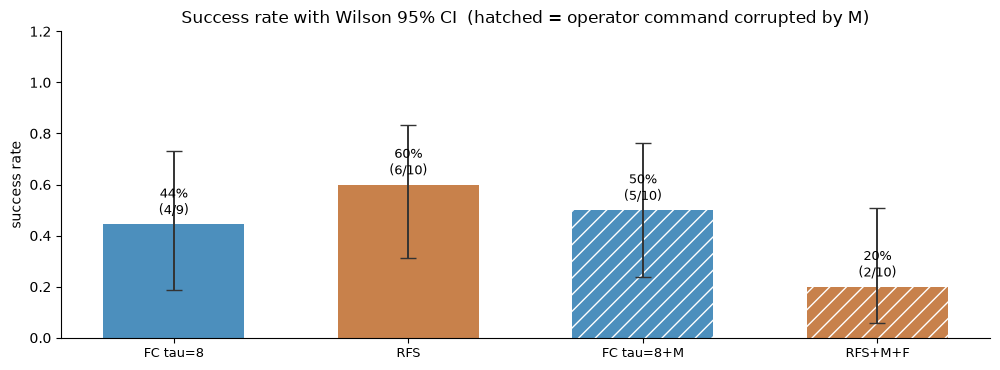

In [6]:
fig, ax = plt.subplots(figsize=(1.9 * len(summary) + 2.5, 3.8))
x = np.arange(len(summary))
rate = summary["success_rate"].to_numpy()
err = np.vstack([rate - summary["ci95_low"], summary["ci95_high"] - rate])
colours = ["#4c8fbd" if m == "shared_flow_control" else "#c8814b" for m in summary["mode"]]
bars = ax.bar(
    x,
    rate,
    width=0.6,
    color=colours,
    hatch=["//" if c else "" for c in summary["corrupted"]],
    edgecolor="white",
    linewidth=0,
)
for bar in bars:
    bar.set_edgecolor("#ffffff")
ax.errorbar(x, rate, yerr=err, fmt="none", ecolor="#333", capsize=6, lw=1.4)
for xi, (r, n, k) in enumerate(zip(rate, summary["trials"], summary["successes"], strict=True)):
    ax.text(xi, r + 0.04, f"{r:.0%}\n({k}/{n})", ha="center", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(summary["label"], fontsize=9)
ax.set_ylim(0, 1.2)
ax.set_ylabel("success rate")
ax.set_title("Success rate with Wilson 95% CI  (hatched = operator command corrupted by M)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Collapsed by factor

The runs form a mode x corruption grid. **Caveat:** if one cell also carries a
flow adapter `F`, that cell is not a clean mode x corruption comparison — the
adapter is confounded with it. The `adapted` column above tells you which.

In [7]:
grid = trials.pivot_table(index="mode", columns="corrupted", values="success", aggfunc=["mean", "count"])
grid.columns = [f"{stat} | {'M applied' if corrupted else 'clean'}" for stat, corrupted in grid.columns]
display(grid.style.format(lambda v: f"{v:.0%}" if isinstance(v, float) else f"{v:.0f}"))

print("Marginal rates (ignore these if the cells are confounded):")
print(trials.groupby("mode")["success"].agg(["mean", "count"]).rename(columns={"mean": "success_rate"}))
print()
print(trials.groupby("corrupted")["success"].agg(["mean", "count"]).rename(columns={"mean": "success_rate"}))

,mean | clean,mean | M applied,count | clean,count | M applied
mode,,,,
shared_flow_control,44%,50%,9,10
shared_reverse_flow_steering,60%,20%,10,10


Marginal rates (ignore these if the cells are confounded):
                              success_rate  count
mode                                             
shared_flow_control               0.473684     19
shared_reverse_flow_steering      0.400000     20

           success_rate  count
corrupted                     
False          0.526316     19
True           0.350000     20


## Paired comparisons

Every run used the same suite, seed and `task_order`, so the trial schedule is
identical: trial *i* is the **same task** in every run. That makes this a
paired design, which is far more sensitive than comparing independent
proportions. Trials missing from a run (a skip) drop out of that pairing.

For paired binary outcomes the right test is **McNemar's**: only trials where
two conditions disagree carry information, so the exact binomial test is
applied to the discordant pairs.

In [8]:
wide = trials.pivot_table(index="trial", columns="run", values="success", aggfunc="first")[ORDER]
tasks = trials.drop_duplicates("trial").set_index("trial")["task_id"]
wide.columns = [LABEL[r] for r in wide.columns]
display(
    wide.assign(task_id=tasks.reindex(wide.index))
    .set_index("task_id", append=True)
    .style.format(lambda v: "" if pd.isna(v) else ("success" if v else "fail"))
)

rows = []
for a, b in combinations(ORDER, 2):
    pair = trials.pivot_table(index="trial", columns="run", values="success", aggfunc="first")[
        [a, b]
    ].dropna()
    a_only = int((pair[a].astype(bool) & ~pair[b].astype(bool)).sum())
    b_only = int((~pair[a].astype(bool) & pair[b].astype(bool)).sum())
    discordant = a_only + b_only
    p = stats.binomtest(b_only, discordant, 0.5).pvalue if discordant else np.nan
    rows.append(
        {
            "A": LABEL[a],
            "B": LABEL[b],
            "paired_trials": len(pair),
            "A_rate": pair[a].mean(),
            "B_rate": pair[b].mean(),
            "A_only": a_only,
            "B_only": b_only,
            "discordant": discordant,
            "mcnemar_p": p,
        }
    )
pairwise = pd.DataFrame(rows)
pairwise.style.format({"A_rate": "{:.0%}", "B_rate": "{:.0%}", "mcnemar_p": "{:.3f}"})

,,FC tau=8,RFS,FC tau=8+M,RFS+M+F
trial,task_id,,,,
0,6,fail,fail,fail,fail
1,6,,success,success,fail
2,0,fail,fail,fail,fail
3,4,fail,fail,fail,fail
4,8,success,success,success,success
5,7,success,success,fail,fail
6,6,fail,success,fail,fail
7,4,fail,fail,success,fail
8,7,success,success,success,success


,A,B,paired_trials,A_rate,B_rate,A_only,B_only,discordant,mcnemar_p
0,FC tau=8,RFS,9,44%,56%,0,1,1,1.000
1,FC tau=8,FC tau=8+M,9,44%,44%,1,1,2,1.000
2,FC tau=8,RFS+M+F,9,44%,22%,2,0,2,0.500
3,RFS,FC tau=8+M,10,60%,50%,2,1,3,1.000
4,RFS,RFS+M+F,10,60%,20%,4,0,4,0.125
5,FC tau=8+M,RFS+M+F,10,50%,20%,3,0,3,0.250


In [9]:
print("Smallest achievable two-sided p for a given number of discordant pairs:")
for d in range(1, 9):
    print(
        f"  {d} discordant -> p >= {stats.binomtest(0, d, 0.5).pvalue:.3f}"
        f"{'   (can never reach 0.05)' if stats.binomtest(0, d, 0.5).pvalue > 0.05 else ''}"
    )
print("\nSo with <= 5 discordant trials no result here can be significant, whatever the direction.")

Smallest achievable two-sided p for a given number of discordant pairs:
  1 discordant -> p >= 1.000   (can never reach 0.05)
  2 discordant -> p >= 0.500   (can never reach 0.05)
  3 discordant -> p >= 0.250   (can never reach 0.05)
  4 discordant -> p >= 0.125   (can never reach 0.05)
  5 discordant -> p >= 0.062   (can never reach 0.05)
  6 discordant -> p >= 0.031
  7 discordant -> p >= 0.016
  8 discordant -> p >= 0.008

So with <= 5 discordant trials no result here can be significant, whatever the direction.


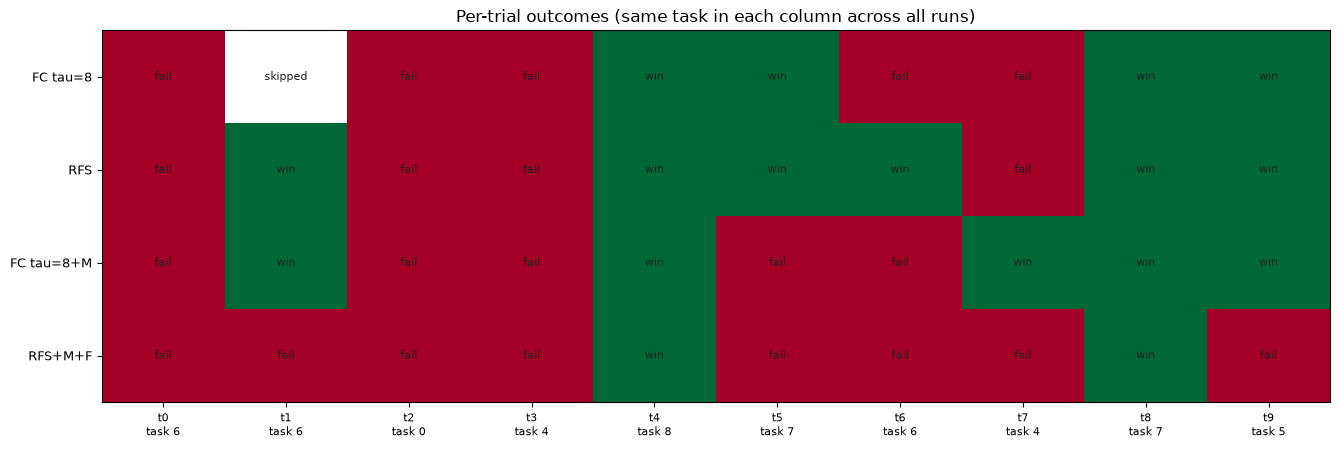

In [10]:
outcomes = wide.to_numpy(dtype=float)
fig, ax = plt.subplots(figsize=(1.0 * len(wide) + 3.5, 0.6 * len(wide.columns) + 2.2))
ax.imshow(np.ma.masked_invalid(outcomes.T), cmap=plt.cm.RdYlGn, vmin=0, vmax=1, aspect="auto")
for j in range(outcomes.shape[1]):
    for i in range(outcomes.shape[0]):
        v = outcomes[i, j]
        ax.text(
            i,
            j,
            "skipped" if np.isnan(v) else ("win" if v else "fail"),
            ha="center",
            va="center",
            fontsize=8,
            color="#222",
        )
ax.set_xticks(range(len(wide)))
ax.set_xticklabels([f"t{t}\ntask {int(tasks[t])}" for t in wide.index], fontsize=8)
ax.set_yticks(range(len(wide.columns)))
ax.set_yticklabels(wide.columns, fontsize=9)
ax.set_title("Per-trial outcomes (same task in each column across all runs)")
plt.tight_layout()
plt.show()

## Per-task view

Tasks repeat within a run (the schedule samples with replacement), so this
also shows how consistent a condition is on the same task.

In [11]:
per_task = trials.pivot_table(
    index=["task_id", "task_description"], columns="label", values="success", aggfunc="mean"
).sort_index()
per_task["n_conditions_solved"] = (per_task > 0).sum(axis=1)
per_task.style.format(lambda v: f"{v:.0%}" if isinstance(v, float) and v <= 1 else f"{v:.0f}")

,label,FC tau=8,FC tau=8+M,RFS,RFS+M+F,n_conditions_solved
task_id,task_description,,,,,
0,open the middle drawer of the cabinet,0%,0%,0%,0%,0
4,put the bowl on top of the cabinet,0%,50%,0%,0%,1
5,push the plate to the front of the stove,100%,100%,100%,0%,3
6,put the cream cheese in the bowl,0%,33%,67%,0%,2
7,turn on the stove,100%,50%,100%,50%,4
8,put the bowl on the plate,100%,100%,100%,100%,4


## How long trials took

`steps` is the control-step count (20 Hz). A trial that hits the episode limit
is a timeout, so successes and failures must be read separately — mixing them
makes the mean meaningless.

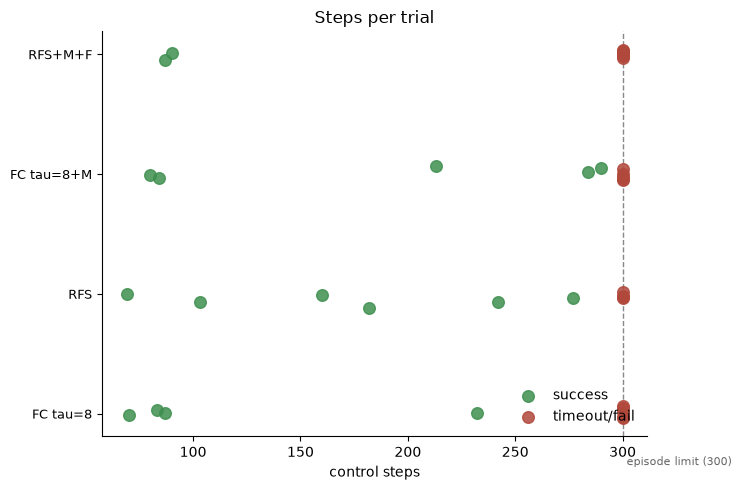

,median steps (success),median seconds (success),timeouts
label,,,
FC tau=8,85.0,6.775,5.0
RFS,171.0,13.055,4.0
FC tau=8+M,213.0,14.750,5.0
RFS+M+F,88.5,7.405,8.0


In [12]:
limit = trials["steps"].max()
rng = np.random.default_rng(0)
fig, ax = plt.subplots(figsize=(7.5, 0.75 * len(ORDER) + 2))
for i, run in enumerate(ORDER):
    group = trials[trials["run"] == run]
    for flag, colour, name in ((True, "#3f8f4f", "success"), (False, "#b1483c", "timeout/fail")):
        subset = group.loc[group["success"] == flag, "steps"]
        ax.scatter(
            subset,
            np.full(len(subset), i) + rng.normal(0, 0.05, len(subset)),
            color=colour,
            s=70,
            alpha=0.85,
            label=name if i == 0 else None,
            zorder=3,
        )
ax.axvline(limit, ls="--", lw=1, color="#888")
ax.text(limit, -0.45, f" episode limit ({int(limit)})", fontsize=8, color="#666", va="bottom")
ax.set_yticks(range(len(ORDER)))
ax.set_yticklabels([LABEL[r] for r in ORDER], fontsize=9)
ax.set_xlabel("control steps")
ax.set_title("Steps per trial")
ax.legend(frameon=False, loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

trials.groupby("label", sort=False).apply(
    lambda g: pd.Series(
        {
            "median steps (success)": g.loc[g["success"], "steps"].median(),
            "median seconds (success)": g.loc[g["success"], "duration_s"].median(),
            "timeouts": int((g["steps"] >= limit).sum()),
        }
    ),
    include_groups=False,
)

## How much the operator actually steered

Each mode consumes the teleop input differently, so raw sample counts are
**not** comparable across modes: `shared_flow_control` reads the input once per
guided denoising step (`tau` per chunk) while `shared_reverse_flow_steering`
reads it once per chunk. What *is* comparable is what the `.npz` records per
control step: the operator's command before any corruption
(`user_translation_raw`), i.e. how much of the trial they spent pushing.

In [13]:
def input_activity(row) -> pd.Series:
    """Per-trial operator engagement from the step arrays."""
    z = np.load(Path(row["run_dir"]) / row["steps_file"])
    raw = z["user_translation_raw"]
    served = z["user_translation"]
    active = np.abs(raw).max(axis=1) >= DEADBAND
    return pd.Series(
        {
            "n_steps": len(raw),
            "commanding_frac": float(active.mean()),
            "mean_speed_when_active": float(np.linalg.norm(raw[active], axis=1).mean())
            if active.any()
            else 0.0,
            "mean_corruption_shift": float(np.linalg.norm((served - raw)[active], axis=1).mean())
            if active.any()
            else 0.0,
            "gripper_closed_frac": float((z["user_gripper"] > 0).mean()),
            # per-step deltas, so this is per-trial even for runs recorded before
            # experiment.py stopped writing a session-cumulative `user_reads`
            "reads_this_trial": int(z["user_reads"].sum()),
        }
    )


activity = trials.join(trials.apply(input_activity, axis=1), rsuffix="_npz")
activity.groupby("label", sort=False)[
    ["commanding_frac", "mean_speed_when_active", "mean_corruption_shift", "gripper_closed_frac"]
].mean().round(3)

,commanding_frac,mean_speed_when_active,mean_corruption_shift,gripper_closed_frac
label,,,,
FC tau=8,0.464,0.803,0.000,0.0
RFS,0.615,0.824,0.000,0.0
FC tau=8+M,0.667,0.853,0.304,0.0
RFS+M+F,0.838,0.810,0.316,0.0


In [14]:
# `reads_this_trial` comes from the step arrays; the mode-specific columns only
# exist for the mode that produces them, hence the NaNs.
metrics = [
    "reads_this_trial",
    "n_steps",
    "guided_denoising_steps",
    "steered_chunks",
    "reconstruction_error_mean",
]
present = [m for m in metrics if m in activity.columns]
steering = activity.groupby("label", sort=False)[present].mean()
steering["reads_per_step"] = steering["reads_this_trial"] / steering["n_steps"]
print("Mean per trial (NaN = the metric does not apply to that mode):")
steering.round(2)

Mean per trial (NaN = the metric does not apply to that mode):


,reads_this_trial,n_steps,guided_denoising_steps,steered_chunks,reconstruction_error_mean,reads_per_step
label,,,,,,
FC tau=8,176.89,219.11,91.67,NaN,NaN,0.81
RFS,22.60,223.30,NaN,15.2,0.59,0.10
FC tau=8+M,197.60,245.10,146.00,NaN,NaN,0.81
RFS+M+F,25.80,257.70,NaN,22.5,0.87,0.10


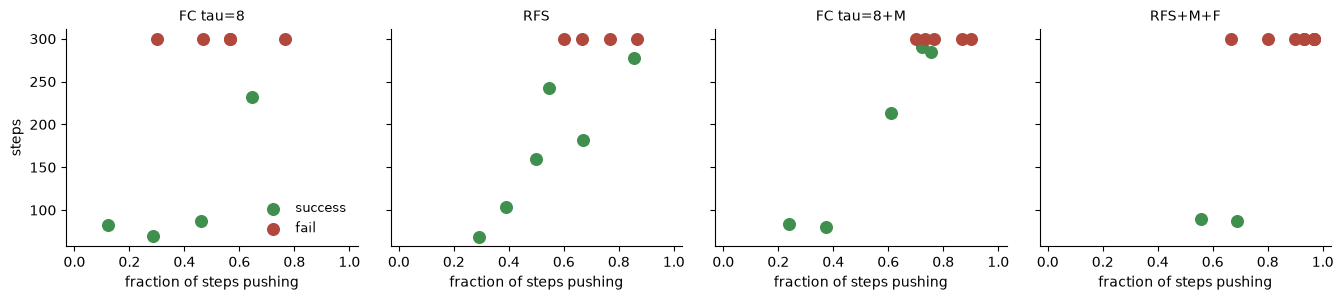

In [15]:
fig, axes = plt.subplots(1, len(ORDER), figsize=(3.4 * len(ORDER), 3.1), sharey=True, squeeze=False)
for ax, run in zip(axes[0], ORDER, strict=True):
    group = activity[activity["run"] == run]
    ok = group["success"].astype(bool)
    ax.scatter(
        group.loc[ok, "commanding_frac"], group.loc[ok, "steps"], color="#3f8f4f", s=70, label="success"
    )
    ax.scatter(
        group.loc[~ok, "commanding_frac"], group.loc[~ok, "steps"], color="#b1483c", s=70, label="fail"
    )
    ax.set_title(LABEL[run], fontsize=10)
    ax.set_xlabel("fraction of steps pushing")
    ax.set_xlim(-0.03, 1.03)
    ax.spines[["top", "right"]].set_visible(False)
axes[0][0].set_ylabel("steps")
axes[0][0].legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

## Findings and caveats

Run the cell below for the headline numbers of whatever runs are loaded.

**Caveats:**

1. **The samples are far too small.** ~10 trials per condition. The Wilson
   intervals span roughly 20-80% and overlap heavily, and the paired tests rest
   on a handful of discordant trials — see the "smallest achievable p" cell:
   with 5 or fewer discordant trials, no result can reach p < 0.05 in either
   direction.
2. **One operator, unblinded, runs back to back.** The same person drove every
   condition knowing which was which, on the same task schedule each time.
   Practice accumulates across runs and is inseparable from condition here;
   in chronological order it works *against* later runs looking worse and *for*
   them looking better.
3. **A confounded cell.** If a run applies both a corruption `M` and an adapter
   `F`, its result cannot be attributed to either alone — check the `adapted`
   column of the summary before reading the mode x corruption grid.
4. **A skipped trial breaks one pair**, so unpaired and paired rates differ
   slightly for that run.
5. **Success is the environment's own flag** at episode end. It says nothing
   about *how* the task was accomplished — in particular, not how much of the
   work was the operator's versus the policy's.
6. **Timeouts dominate the failures**, so `steps` mostly measures the episode
   limit for failures; only compare durations among successes.

A powered version of this comparison needs a pre-registered trial count (order
of 100+ per condition), condition order counterbalanced, one factor varied at a
time, and ideally several operators.

In [16]:
print("Success rate per run (chronological):\n")
for run in ORDER:
    row = summary.loc[run]
    flags = []
    if row["corrupted"]:
        flags.append("command corrupted by M")
    if row["adapted"]:
        flags.append("reversal adapted by F")
    print(
        f"  {row['label']:14s} {row['successes']}/{row['trials']} = {row['success_rate']:.0%} "
        f"(95% CI {row['ci95_low']:.0%}-{row['ci95_high']:.0%})"
        + (f"   [{'; '.join(flags)}]" if flags else "")
    )

best, worst = summary["success_rate"].idxmax(), summary["success_rate"].idxmin()
print(
    f"\nHighest: {summary.loc[best, 'label']} ({summary.loc[best, 'success_rate']:.0%}); "
    f"lowest: {summary.loc[worst, 'label']} ({summary.loc[worst, 'success_rate']:.0%})."
)

significant = pairwise[pairwise["mcnemar_p"] < 0.05]
print(f"\nPairwise comparisons reaching p < 0.05: {len(significant)} of {len(pairwise)}.")
print(
    f"Most suggestive contrast: "
    f"{pairwise.loc[pairwise['mcnemar_p'].idxmin(), 'A']} vs "
    f"{pairwise.loc[pairwise['mcnemar_p'].idxmin(), 'B']} "
    f"(p = {pairwise['mcnemar_p'].min():.3f}) — still not significant."
)

Success rate per run (chronological):

  FC tau=8       4/9 = 44% (95% CI 19%-73%)
  RFS            6/10 = 60% (95% CI 31%-83%)
  FC tau=8+M     5/10 = 50% (95% CI 24%-76%)   [command corrupted by M]
  RFS+M+F        2/10 = 20% (95% CI 6%-51%)   [command corrupted by M; reversal adapted by F]

Highest: RFS (60%); lowest: RFS+M+F (20%).

Pairwise comparisons reaching p < 0.05: 0 of 6.
Most suggestive contrast: RFS vs RFS+M+F (p = 0.125) — still not significant.
